In [1]:
!pip install monai==1.3.1 transformers==4.41.0 numpy==1.26.4 nibabel==5.2.1 \
    SimpleITK==2.3.1 einops==0.8.0 peft==0.8.2 safetensors==0.4.3 \
    accelerate sentencepiece matplotlib pandas seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 115.0 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing in

In [1]:
!git clone https://github.com/yuji4/MedSeg3D-KO.git
%cd MedSeg3D-KO

Cloning into 'MedSeg3D-KO'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 154 (delta 59), reused 134 (delta 42), pack-reused 0 (from 0)
Receiving objects: 100% (154/154), 29.38 MiB | 25.87 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/MedSeg3D-KO


In [2]:
import sys, os
import numpy as np
import nibabel as nib
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns
from google.colab import drive

sys.path.insert(0, '/content/MedSeg3D-KO')
drive.mount('/content/drive')
print("완료")

Mounted at /content/drive
완료


In [3]:
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


모델 로드

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "GoodBaiBai88/M3D-LaMed-Phi-3-4B"
tokenizer = AutoTokenizer.from_pretrained(
    model_name, model_max_length=512, padding_side="right",
    use_fast=False, trust_remote_code=True
)
model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.bfloat16,
    device_map='auto', trust_remote_code=True
)
model.eval()
print("모델 로드 성공")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.blocks.patchembedding PatchEmbeddingBlock.__init__:pos_embed: Argument `pos_embed` has been deprecated since version 1.2. It will be removed in version 1.4. please use `proj_type` instead.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.vit ViT.__init__:pos_embed: Argument `pos_embed` has been deprecated since version 1.2. It will be removed in version 1.4. please use `proj_type` instead.
  warn_deprecated(argname, msg, warning_category)


build_sam_vit_3d...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

모델 로드 성공


파이프라인, 유틸 초기화

In [5]:
from src.inference.segmentation import SegmentationPipeline
from src.inference.model_loader import PROJ_OUT_NUM

pipeline = SegmentationPipeline()
pipeline.model = model
pipeline.tokenizer = tokenizer
pipeline._device = next(model.parameters()).device

def dice_score(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    intersection = (pred & gt).sum()
    if pred.sum() + gt.sum() == 0:
        return 1.0
    return 2 * intersection / (pred.sum() + gt.sum())

def iou_score(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    intersection = (pred & gt).sum()
    union = (pred | gt).sum()
    if union == 0:
        return 1.0
    return intersection / union

def run_inference(image_pt, prompt, threshold=0.5):
    full_prompt = "<im_patch>" * PROJ_OUT_NUM + prompt
    input_ids = tokenizer(full_prompt, return_tensors="pt")["input_ids"].to(pipeline._device)
    dtype = next(model.parameters()).dtype
    image_pt = image_pt.to(dtype=dtype, device=pipeline._device)
    with torch.no_grad():
        generation, seg_logit = model.generate(
            image_pt, input_ids, seg_enable=True,
            max_new_tokens=256, do_sample=False
        )
    text = tokenizer.decode(generation[0], skip_special_tokens=True)
    mask = (torch.sigmoid(seg_logit) > threshold).squeeze().cpu().numpy().astype(bool)
    return mask, text, seg_logit

print("파이프라인 준비 완료")

파이프라인 준비 완료


데이터 로드

In [6]:
DATA_ROOT = '/content/drive/MyDrive/Task07_Pancreas_Partially'
cases = ['pancreas_001', 'pancreas_004', 'pancreas_005', 'pancreas_006', 'pancreas_010']

def load_case(case):
    img = nib.load(f'{DATA_ROOT}/imagesTr/{case}.nii/{case}.nii')
    gt  = nib.load(f'{DATA_ROOT}/labelsTr/{case}.nii/{case}.nii')
    arr = img.get_fdata().astype(np.float32).transpose(2, 1, 0)
    gt_arr = (gt.get_fdata().astype(np.uint8).transpose(2, 1, 0) == 1)
    return arr, gt_arr

arr, gt = load_case('pancreas_001')
print("CT shape:", arr.shape)
print("GT 복셀:", gt.sum())

CT shape: (110, 512, 512)
GT 복셀: 39557


프롬프트 정의

In [7]:
prompt_groups = {

    # ── Baseline: M3D 학습 템플릿과 유사한 기준형 ──────────────────────────
    "Baseline": {
        "B1": "Segment the pancreas in this image.",
        "B2": "Can you segment the pancreas in this image?",
        "B3": "Please segment the pancreas in this image and output the mask.",
    },

    # ── Group 1: Length Ablation — 길이가 성능에 미치는 영향 ────────────────
    "Length": {
        "L1": "pancreas",
        "L2": "segment pancreas",
        "L3": "Segment the pancreas in this image.",
        "L4": "Please carefully identify and segment the pancreatic tissue from this CT image and output the segmentation mask.",
    },

    # ── Group 2: Spatial Prior — 해부학 위치 힌트가 성능 개선하는가 ───────────
    "Spatial": {
        "S1": "Segment the pancreas posterior to the stomach.",
        "S2": "Segment the pancreas in the upper abdomen.",
        "S3": "Segment the pancreas near the spleen and duodenum.",
        "S4": "Segment the retroperitoneal pancreas.",
    },

    # ── Group 3: Lexical Variation — 동사 종류가 성능에 영향 주는가 ──────────
    "Lexical": {
        "V1": "segment pancreas",
        "V2": "identify pancreas",
        "V3": "isolate pancreas",
        "V4": "extract pancreatic tissue",
    },

    # ── Group 4: Structured Prompt — 구조화된 형식이 conditioning 안정성 높이나 ─
    "Structured": {
        "T1": "[TASK] segmentation\n[ORGAN] pancreas",
        "T2": "task: segmentation\norgan: pancreas\noutput: mask",
        "T3": '{"task":"segmentation","organ":"pancreas"}',
        "T4": "ORGAN=pancreas\nTASK=segmentation",
    },

    # ── Group 5: Chain-of-Thought — reasoning이 segmentation에 도움 되나 ────
    "CoT": {
        "CoT1": "Step 1: Locate the stomach. Step 2: Find the pancreas posterior to it. Step 3: Segment the pancreas.",
        "CoT2": "First identify abdominal organs, then segment the pancreas.",
        "CoT3": "Reason step-by-step and segment the pancreas.",
    },
}

# 전체 프롬프트 수 확인
total = sum(len(v) for v in prompt_groups.values())
print(f"총 프롬프트: {total}개")
print(f"총 추론 횟수: {total} × {len(cases)} = {total * len(cases)}번")

총 프롬프트: 22개
총 추론 횟수: 22 × 5 = 110번


메인 실험 진행

In [8]:
all_results = {}  # {group: {prompt_id: [dice_per_case]}}

for group_name, prompts in prompt_groups.items():
    all_results[group_name] = {pid: [] for pid in prompts}
    print(f"\n{'='*50}")
    print(f"그룹: {group_name}")
    print(f"{'='*50}")

    for case in cases:
        print(f"\n  --- {case} ---")
        arr, gt_pancreas = load_case(case)
        preprocessed, _ = pipeline._prepare_image_pt(arr)

        for pid, prompt in prompts.items():
            try:
                mask, text, _ = run_inference(preprocessed, prompt)
                mask_full = pipeline._resize_mask(mask, arr.shape)
                dice = dice_score(mask_full, gt_pancreas)
                iou  = iou_score(mask_full, gt_pancreas)
                all_results[group_name][pid].append({
                    "dice": dice,
                    "iou": iou,
                    "pred_voxels": int(mask_full.sum()),
                    "text": text[:50],
                })
                print(f"  {pid}: Dice={dice:.4f} | IoU={iou:.4f} | pred={mask_full.sum()} | {text[:40]}")
            except Exception as e:
                print(f"  {pid}: 오류 - {e}")
                all_results[group_name][pid].append({
                    "dice": 0.0, "iou": 0.0,
                    "pred_voxels": 0, "text": "error"
                })

print("\n실험 완료!")


그룹: Baseline

  --- pancreas_001 ---


You are not running the flash-attention implementation, expect numerical differences.


  B1: Dice=0.5036 | IoU=0.3366 | pred=68872 | The segmentation reveals  [SEG] .
  B2: Dice=0.5040 | IoU=0.3369 | pred=70244 | The segmentation reveals  [SEG] .
  B3: Dice=0.5035 | IoU=0.3365 | pred=70452 | The segmentation reveals  [SEG] .

  --- pancreas_004 ---
  B1: Dice=0.5403 | IoU=0.3701 | pred=82484 | The segmentation reveals  [SEG] .
  B2: Dice=0.5411 | IoU=0.3709 | pred=84180 | The segmentation reveals  [SEG] .
  B3: Dice=0.5413 | IoU=0.3711 | pred=84276 | The segmentation reveals  [SEG] .

  --- pancreas_005 ---
  B1: Dice=0.5952 | IoU=0.4237 | pred=41908 | The segmentation reveals  [SEG] .
  B2: Dice=0.6118 | IoU=0.4407 | pred=44004 | The segmentation reveals  [SEG] .
  B3: Dice=0.6104 | IoU=0.4392 | pred=43848 | The segmentation reveals  [SEG] .

  --- pancreas_006 ---
  B1: Dice=0.5314 | IoU=0.3618 | pred=40680 | The segmentation reveals  [SEG] .
  B2: Dice=0.5388 | IoU=0.3688 | pred=42080 | The segmentation reveals  [SEG] .
  B3: Dice=0.5381 | IoU=0.3681 | pred=41928 | Th

In [9]:
# 결과 DataFrame 생성

rows = []
for group_name, prompts in all_results.items():
    for pid, case_results in prompts.items():
        prompt_text = prompt_groups[group_name][pid]
        dices = [r["dice"] for r in case_results]
        ious  = [r["iou"]  for r in case_results]
        rows.append({
            "group":        group_name,
            "prompt_id":    pid,
            "prompt":       prompt_text[:60],
            "mean_dice":    np.mean(dices),
            "std_dice":     np.std(dices),
            "max_dice":     np.max(dices),
            "min_dice":     np.min(dices),
            "mean_iou":     np.mean(ious),
            "token_length": len(tokenizer.encode(prompt_text)),
        })

df = pd.DataFrame(rows).sort_values("mean_dice", ascending=False)
print(df[["group", "prompt_id", "mean_dice", "std_dice", "mean_iou", "token_length"]].to_string(index=False))

     group prompt_id  mean_dice  std_dice  mean_iou  token_length
  Baseline        B2   0.551748  0.035462  0.381814            12
  Baseline        B3   0.551338  0.035191  0.381409            15
       CoT      CoT2   0.550719  0.034195  0.380771            16
       CoT      CoT1   0.550456  0.036486  0.380624            36
    Length        L4   0.548701  0.031992  0.378752            23
       CoT      CoT3   0.547738  0.030500  0.377772            15
   Spatial        S2   0.547716  0.030701  0.377762            14
  Baseline        B1   0.546764  0.030839  0.376862            11
    Length        L3   0.546764  0.030839  0.376862            11
   Spatial        S3   0.543543  0.026474  0.373652            17
   Spatial        S1   0.540542  0.026624  0.370832            14
Structured        T3   0.437572  0.221782  0.302022            13
Structured        T2   0.436601  0.219724  0.300632            15
   Spatial        S4   0.433018  0.217411  0.297100            13
    Length

/tmp/ipykernel_5412/1479353484.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/tmp/ipykernel_5412/1479353484.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/tmp/ipykernel_5412/1479353484.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/tmp/ipykernel_5412/1479353484.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/tmp/ipykernel_5412/1479353484.py:14

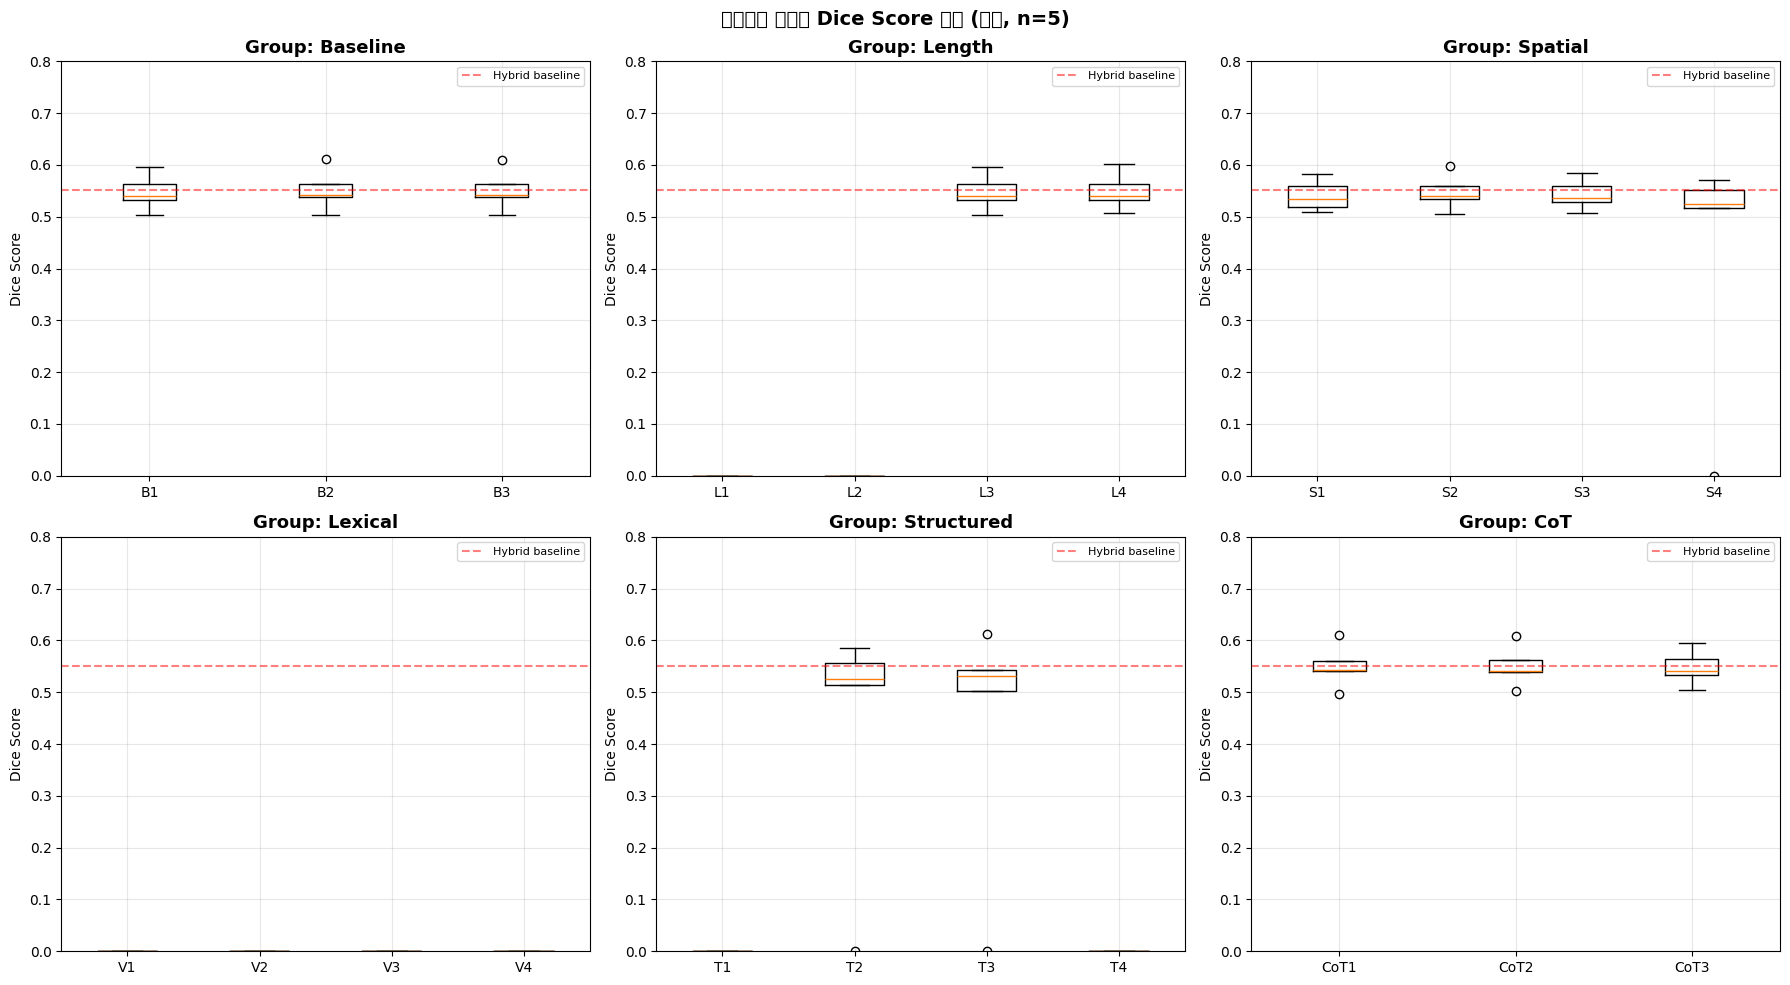

In [10]:
# 그룹별 Dice 박스플롯 시각화

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (group_name, prompts) in enumerate(all_results.items()):
    ax = axes[idx]
    data = []
    labels = []
    for pid, case_results in prompts.items():
        data.append([r["dice"] for r in case_results])
        labels.append(pid)

    ax.boxplot(data, labels=labels)
    ax.set_title(f"Group: {group_name}", fontsize=13, fontweight='bold')
    ax.set_ylabel("Dice Score")
    ax.set_ylim(0, 0.8)
    ax.axhline(y=0.5515, color='red', linestyle='--', alpha=0.5, label='Hybrid baseline')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("프롬프트 그룹별 Dice Score 분포 (췌장, n=5)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("exp_boxplot.png", dpi=150)
plt.show()

In [12]:
# 한국어 폰트 설치
!apt-get install -y fonts-nanum
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm._load_fontmanager(try_read_cache=False)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
print("완료")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (49.9 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
완료


전체 프롬프트 Dice 막대그래프 (상위 10개 강조)

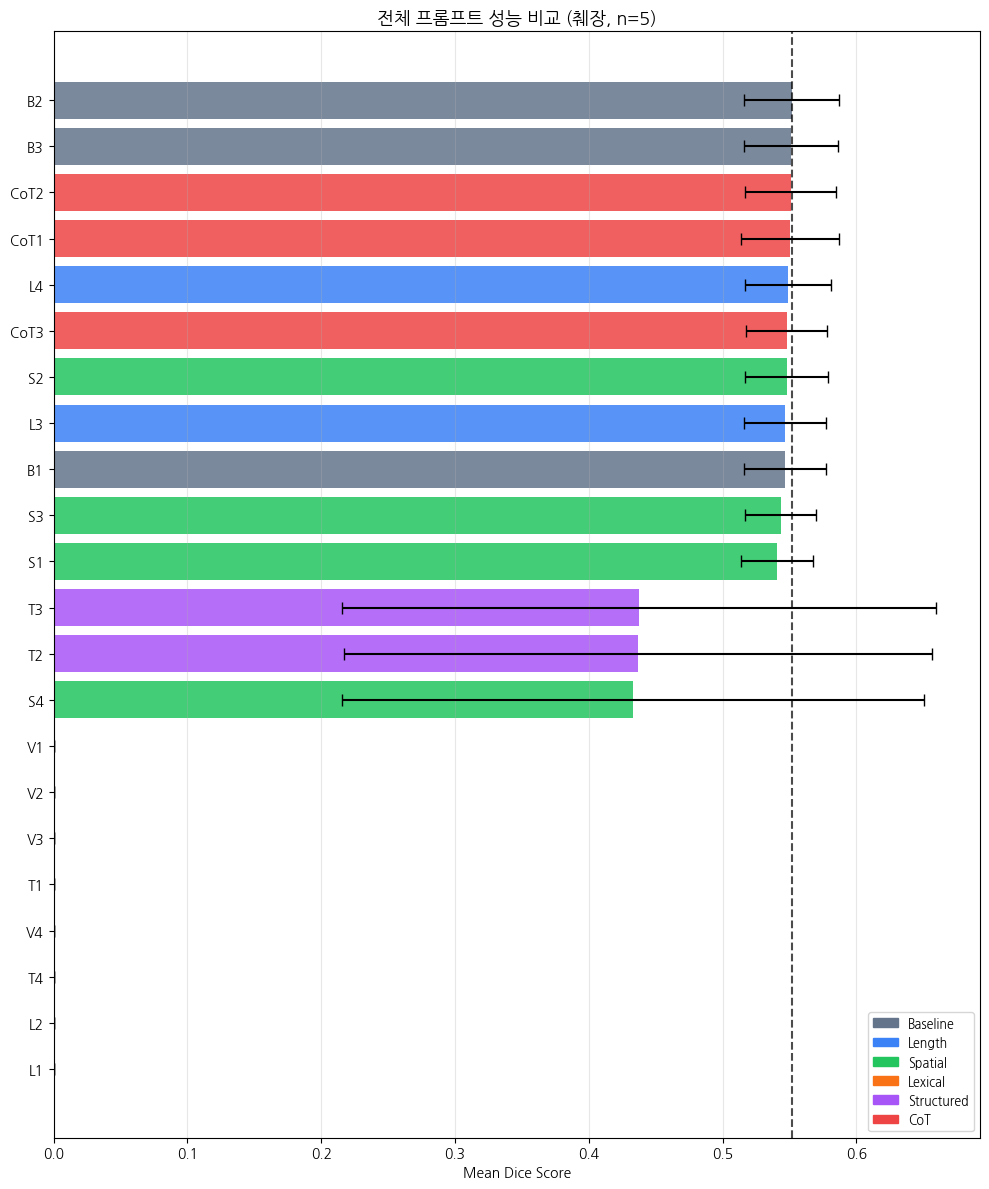

In [14]:
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'

df_sorted = df.sort_values("mean_dice", ascending=True)

colors = []
group_colors = {
    "Baseline":   "#64748b",
    "Length":     "#3b82f6",
    "Spatial":    "#22c55e",
    "Lexical":    "#f97316",
    "Structured": "#a855f7",
    "CoT":        "#ef4444",
}
for _, row in df_sorted.iterrows():
    colors.append(group_colors[row["group"]])

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(
    df_sorted["prompt_id"],
    df_sorted["mean_dice"],
    xerr=df_sorted["std_dice"],
    color=colors, alpha=0.85, capsize=4
)
ax.axvline(x=0.5515, color='black', linestyle='--', alpha=0.7, label='Hybrid baseline (0.5515)')
ax.set_xlabel("Mean Dice Score")
ax.set_title("전체 프롬프트 성능 비교 (췌장, n=5)", fontsize=13, fontweight='bold')
ax.legend()

patches = [mpatches.Patch(color=c, label=g) for g, c in group_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("exp_all_prompts.png", dpi=150)
plt.show()

Token Length vs Dice 산점도
- "프롬프트 길이가 성능에 영향 주는가?" 분석

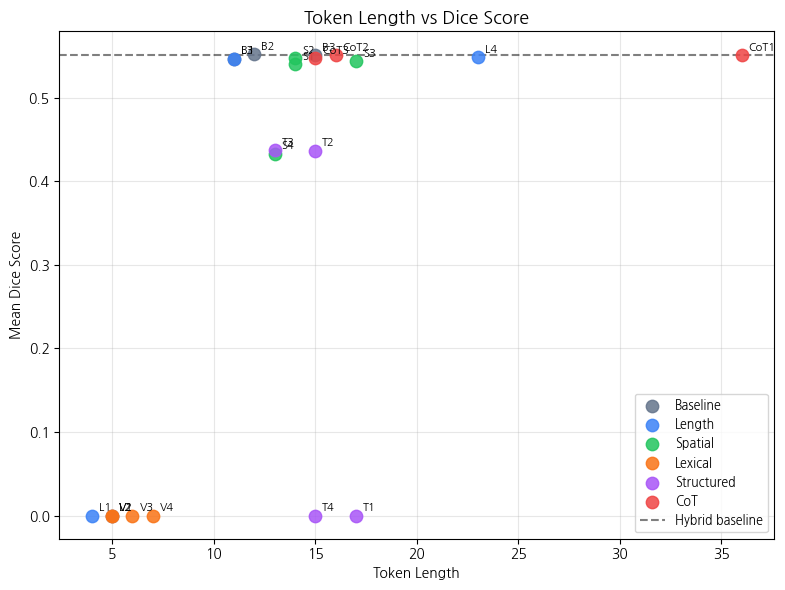

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for group_name, color in group_colors.items():
    subset = df[df["group"] == group_name]
    ax.scatter(
        subset["token_length"],
        subset["mean_dice"],
        c=color, label=group_name,
        s=80, alpha=0.85, zorder=3
    )
    for _, row in subset.iterrows():
        ax.annotate(
            row["prompt_id"],
            (row["token_length"], row["mean_dice"]),
            textcoords="offset points", xytext=(5, 3),
            fontsize=8
        )

ax.axhline(y=0.5515, color='black', linestyle='--', alpha=0.5, label='Hybrid baseline')
ax.set_xlabel("Token Length")
ax.set_ylabel("Mean Dice Score")
ax.set_title("Token Length vs Dice Score", fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("exp_token_vs_dice.png", dpi=150)
plt.show()

Failure Case 시각화
- 최고 vs 최저 프롬프트 비교

최고: B2 (Baseline) Dice=0.5517
최저: S4 (Spatial) Dice=0.4330


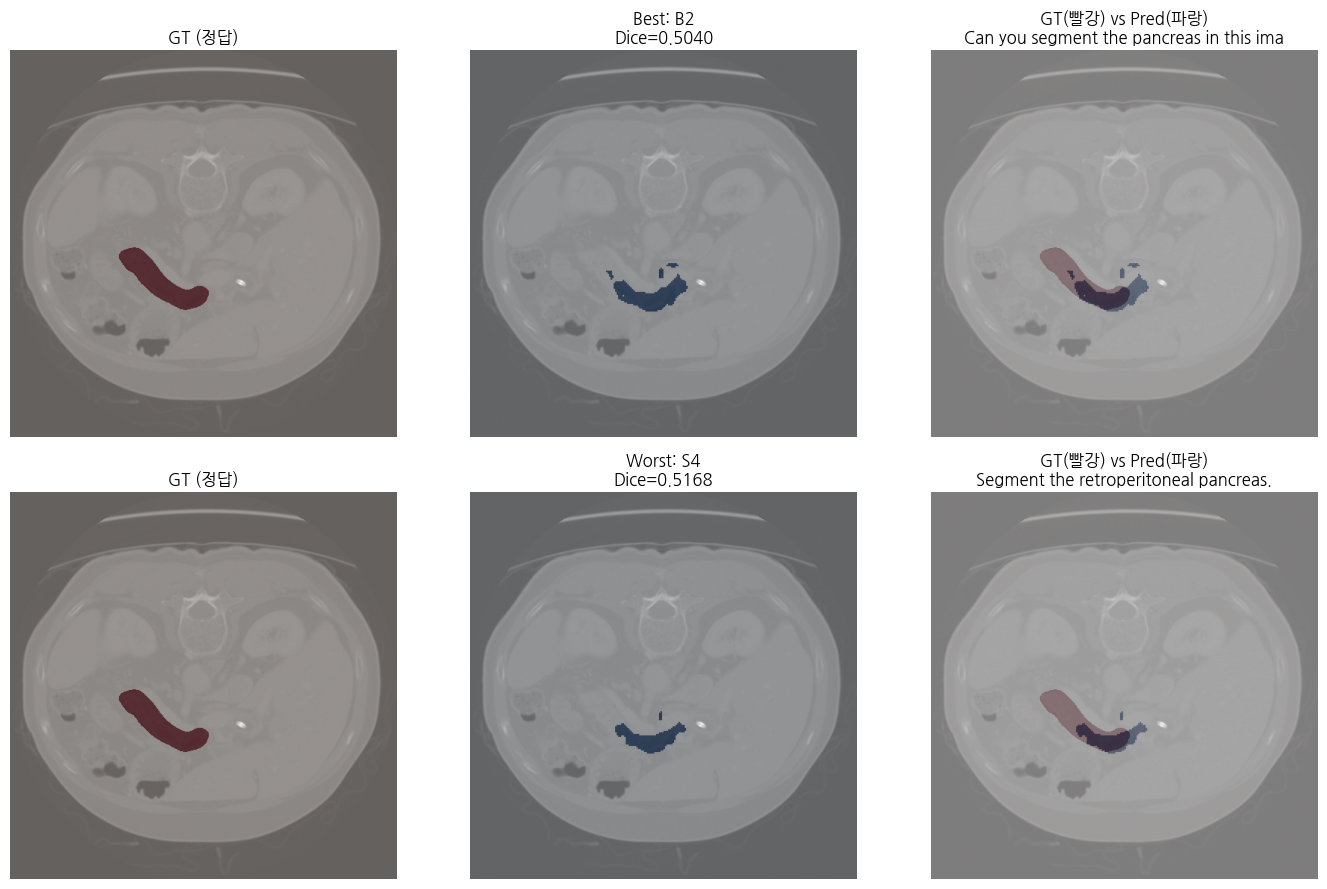

In [16]:
best_row  = df.iloc[0]
worst_row = df[df["mean_dice"] > 0].iloc[-1]

print(f"최고: {best_row['prompt_id']} ({best_row['group']}) Dice={best_row['mean_dice']:.4f}")
print(f"최저: {worst_row['prompt_id']} ({worst_row['group']}) Dice={worst_row['mean_dice']:.4f}")

arr, gt_pancreas = load_case('pancreas_001')
preprocessed, _ = pipeline._prepare_image_pt(arr)
mid = arr.shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for row_idx, (label, pid, group) in enumerate([
    ("Best",  best_row["prompt_id"],  best_row["group"]),
    ("Worst", worst_row["prompt_id"], worst_row["group"]),
]):
    prompt = prompt_groups[group][pid]
    mask, text, _ = run_inference(preprocessed, prompt)
    mask_full = pipeline._resize_mask(mask, arr.shape)
    dice = dice_score(mask_full, gt_pancreas)

    axes[row_idx, 0].imshow(arr[mid], cmap='gray')
    axes[row_idx, 0].imshow(gt_pancreas[mid], alpha=0.4, cmap='Reds')
    axes[row_idx, 0].set_title("GT (정답)")
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(arr[mid], cmap='gray')
    axes[row_idx, 1].imshow(mask_full[mid], alpha=0.4, cmap='Blues')
    axes[row_idx, 1].set_title(f"{label}: {pid}\nDice={dice:.4f}")
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(arr[mid], cmap='gray')
    axes[row_idx, 2].imshow(gt_pancreas[mid], alpha=0.3, cmap='Reds')
    axes[row_idx, 2].imshow(mask_full[mid], alpha=0.3, cmap='Blues')
    axes[row_idx, 2].set_title(f"GT(빨강) vs Pred(파랑)\n{prompt[:40]}")
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig("exp_failure_cases.png", dpi=150)
plt.show()

그룹별 평균 Dice 비교 + 최종 결론

In [17]:
print("=" * 60)
print("그룹별 평균 Dice")
print("=" * 60)
group_summary = df.groupby("group")["mean_dice"].agg(["mean", "max", "std"])
group_summary.columns = ["그룹평균", "그룹최고", "표준편차"]
group_summary = group_summary.sort_values("그룹평균", ascending=False)
print(group_summary.round(4))

print("\n" + "=" * 60)
print("Top 5 최고 프롬프트")
print("=" * 60)
print(df[["group", "prompt_id", "prompt", "mean_dice", "token_length"]].head(5).to_string(index=False))

print("\n" + "=" * 60)
print("Hybrid baseline 대비 개선된 프롬프트")
print("=" * 60)
improved = df[df["mean_dice"] > 0.5515]
print(improved[["group", "prompt_id", "mean_dice", "prompt"]].to_string(index=False))

그룹별 평균 Dice
              그룹평균    그룹최고    표준편차
group                             
Baseline    0.5500  0.5517  0.0028
CoT         0.5496  0.5507  0.0017
Spatial     0.5162  0.5477  0.0555
Length      0.2739  0.5487  0.3162
Structured  0.2185  0.4376  0.2524
Lexical     0.0000  0.0000  0.0000

Top 5 최고 프롬프트
   group prompt_id                                                       prompt  mean_dice  token_length
Baseline        B2                  Can you segment the pancreas in this image?   0.551748            12
Baseline        B3 Please segment the pancreas in this image and output the mas   0.551338            15
     CoT      CoT2  First identify abdominal organs, then segment the pancreas.   0.550719            16
     CoT      CoT1 Step 1: Locate the stomach. Step 2: Find the pancreas poster   0.550456            36
  Length        L4 Please carefully identify and segment the pancreatic tissue    0.548701            23

Hybrid baseline 대비 개선된 프롬프트
   group prompt_id  mean_dice     